# Double DQN — LunarLander-v3

## 1. Konfiguracja

In [1]:
import torch
import random
import numpy as np
import gymnasium as gym
import warnings

SEED = 42
OPTIMIZE_WITH_HARDWARE = True

device = torch.device('cpu')
if OPTIMIZE_WITH_HARDWARE:
    if torch.backends.mps.is_available():
        device = torch.device('mps')
        print('Wybrano urz\u0105dzenie: MPS')
    elif torch.cuda.is_available():
        device = torch.device('cuda')
        print('Wybrano urz\u0105dzenie: GPU z obs\u0142ug\u0105 CUDA')
        print(f'Nazwa urz\u0105dzenia CUDA: {torch.cuda.get_device_name()}')
else:
    print('Wybrano urz\u0105dzenie: CPU')

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

warnings.filterwarnings("ignore")

Wybrano urządzenie: GPU z obsługą CUDA
Nazwa urządzenia CUDA: NVIDIA GeForce RTX 3060 Laptop GPU


## 2. Inicjalizacja środowiska

In [2]:
env = gym.make("LunarLander-v3", render_mode="human")
env.action_space.seed(SEED)
env.observation_space.seed(SEED)

state, _ = env.reset(seed=SEED)

terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    result = env.step(action)
    
    next_state, reward, terminated, truncated, info = result
    done = terminated or truncated
    
    env.render()
    if done:
        break

env.close()

print(f'Ilo\u015b\u0107 mo\u017cliwych akcji: {env.action_space.n}')

Ilość możliwych akcji: 4


## 3. Hiperparametry

In [3]:
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.995
MEMORY_SIZE = 100000
TRAIN_START = 1000
TARGET_UPDATE_STEPS = 1000
MAX_EPISODES = 500
MAX_STEPS = 1000
HIDDEN_SIZES = (128, 128)

## 4. Sieć neuronowa

In [4]:
import torch.nn as nn


class DQNetwork(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=HIDDEN_SIZES):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, state):
        return self.net(state)

## 5. Agent DQN

In [5]:
from collections import deque


class DQNAgent:
    def __init__(self, input_size, output_size):
        self.output_size = output_size
        self.epsilon = EPSILON_START
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.total_steps = 0
        self.model = DQNetwork(input_size, output_size).to(device)
        self.target_model = DQNetwork(input_size, output_size).to(device)
        self.update_target_model()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=LEARNING_RATE)
        self.loss_function = nn.SmoothL1Loss()

    def update_target_model(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def memorize(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.output_size)
        state = torch.FloatTensor(state).to(device).unsqueeze(0)
        with torch.no_grad():
            return torch.argmax(self.model(state)).item()

    def replay(self):
        if len(self.memory) < TRAIN_START:
            return None
        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)
        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(np.array(dones, dtype=np.float32)).unsqueeze(1).to(device)

        q_values = self.model(states).gather(1, actions)
        next_actions = self.model(next_states).argmax(1).unsqueeze(1)
        next_q_values = self.target_model(next_states).gather(1, next_actions).detach()
        target_q_values = rewards + GAMMA * next_q_values * (1 - dones)

        loss = self.loss_function(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        self.optimizer.step()

        self.total_steps += 1
        if self.total_steps % TARGET_UPDATE_STEPS == 0:
            self.update_target_model()

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(EPSILON_MIN, self.epsilon * EPSILON_DECAY)

## 6. Trening

In [6]:
env = gym.make("LunarLander-v3")
env.action_space.seed(SEED)
env.observation_space.seed(SEED)
input_size = env.observation_space.shape[0]
output_size = env.action_space.n
agent = DQNAgent(input_size, output_size)

rewards_history = []
loss_history = []
length_history = []
epsilon_history = []

for episode in range(MAX_EPISODES):
    state, _ = env.reset()
    
    total_reward = 0.0
    done = False
    step = 0
    episode_losses = []

    while not done and step < MAX_STEPS:
        action = agent.act(state)
        result = env.step(action)
        
        next_state, reward, terminated, truncated, info = result
        done = terminated or truncated

        agent.memorize(state, action, reward, next_state, done)
        total_reward += float(reward)
        state = next_state
        loss = agent.replay()
        if loss is not None:
            episode_losses.append(loss)
        step += 1

    agent.decay_epsilon()
    rewards_history.append(total_reward)
    length_history.append(step)
    epsilon_history.append(agent.epsilon)
    avg_loss = np.mean(episode_losses) if len(episode_losses) > 0 else 0
    loss_history.append(avg_loss)
    if episode % 10 == 0:
        print(f"Epizod {episode}/{MAX_EPISODES}, Nagroda: {total_reward:.2f}, Strata: {avg_loss:.4f}, Kroki: {step}, Epsilon: {agent.epsilon:.3f}")

env.close()

Epizod 0/500, Nagroda: -69.83, Strata: 0.0000, Kroki: 70, Epsilon: 0.995
Epizod 10/500, Nagroda: -264.06, Strata: 0.0000, Kroki: 116, Epsilon: 0.946
Epizod 20/500, Nagroda: -99.93, Strata: 1.8695, Kroki: 66, Epsilon: 0.900
Epizod 30/500, Nagroda: -70.39, Strata: 1.7769, Kroki: 99, Epsilon: 0.856
Epizod 40/500, Nagroda: -40.39, Strata: 1.4802, Kroki: 141, Epsilon: 0.814
Epizod 50/500, Nagroda: -84.83, Strata: 1.7138, Kroki: 83, Epsilon: 0.774
Epizod 60/500, Nagroda: -94.88, Strata: 2.1016, Kroki: 77, Epsilon: 0.737
Epizod 70/500, Nagroda: -106.18, Strata: 1.5075, Kroki: 137, Epsilon: 0.701
Epizod 80/500, Nagroda: -4.25, Strata: 1.4031, Kroki: 129, Epsilon: 0.666
Epizod 90/500, Nagroda: -48.36, Strata: 1.4040, Kroki: 182, Epsilon: 0.634
Epizod 100/500, Nagroda: -64.21, Strata: 1.3826, Kroki: 121, Epsilon: 0.603
Epizod 110/500, Nagroda: -70.50, Strata: 1.1213, Kroki: 111, Epsilon: 0.573
Epizod 120/500, Nagroda: -22.27, Strata: 1.2142, Kroki: 79, Epsilon: 0.545
Epizod 130/500, Nagroda: 30.

In [7]:
torch.save({
    'model_state_dict': agent.model.state_dict(),
    'optimizer_state_dict': agent.optimizer.state_dict(),
    'epsilon': agent.epsilon,
}, 'dqn_lunar_lander.pth')

## 7. Wizualizacja wyników

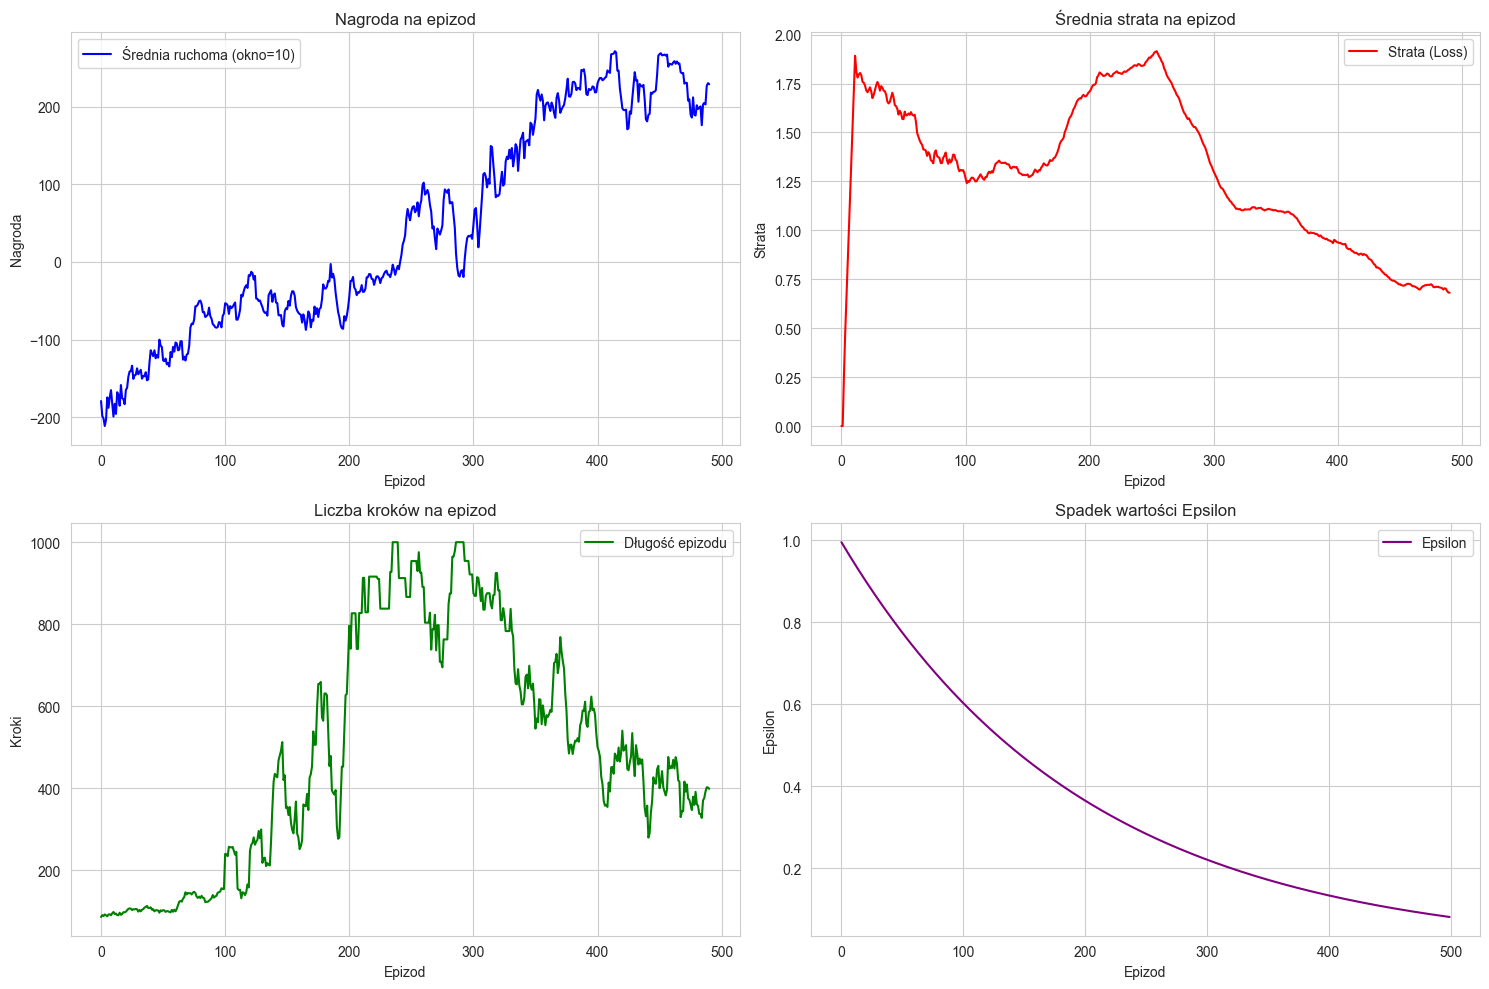

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

window_size = 10
def moving_average(data, w=10):
    if len(data) < w: 
        return data
    return np.convolve(data, np.ones(w) / w, mode='valid')

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# 1. Nagrody
axs[0, 0].plot(moving_average(rewards_history, window_size), label=f"\u015arednia ruchoma (okno={window_size})", color='blue')
axs[0, 0].set_title("Nagroda na epizod")
axs[0, 0].set_xlabel("Epizod")
axs[0, 0].set_ylabel("Nagroda")
axs[0, 0].legend()

# 2. Strata (Loss)
axs[0, 1].plot(moving_average(loss_history, window_size), label="Strata (Loss)", color='red')
axs[0, 1].set_title("\u015arednia strata na epizod")
axs[0, 1].set_xlabel("Epizod")
axs[0, 1].set_ylabel("Strata")
axs[0, 1].legend()

# 3. Długość epizodu
axs[1, 0].plot(moving_average(length_history, window_size), label="D\u0142ugo\u015b\u0107 epizodu", color='green')
axs[1, 0].set_title("Liczba krok\u00f3w na epizod")
axs[1, 0].set_xlabel("Epizod")
axs[1, 0].set_ylabel("Kroki")
axs[1, 0].legend()

# 4. Epsilon
axs[1, 1].plot(epsilon_history, label="Epsilon", color='purple')
axs[1, 1].set_title("Spadek warto\u015bci Epsilon")
axs[1, 1].set_xlabel("Epizod")
axs[1, 1].set_ylabel("Epsilon")
axs[1, 1].legend()

plt.tight_layout()
plt.show()

## 8. Wizualizacja lądowania

In [11]:
checkpoint = torch.load('dqn_lunar_lander.pth', map_location=device)
agent.model.load_state_dict(checkpoint['model_state_dict'])

agent.epsilon = 0.0   # tylko nauczona polityka, bez losowych akcji
EPISODES = 3

env = gym.make("LunarLander-v3", render_mode="human")
env.action_space.seed(SEED)

for episode in range(EPISODES):
    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]
    done = False
    total_reward = 0
    while not done:
        env.render()
        action = agent.act(state)
        result = env.step(action)
        if len(result) == 5:
            state, reward, terminated, truncated, info = result
            done = terminated or truncated
        else:
            state, reward, done, info = result
        total_reward += reward
    print(f"Epizod {episode + 1}: nagroda {total_reward:.2f}")

env.close()

Epizod 1: nagroda 278.64
Epizod 2: nagroda 171.19
Epizod 3: nagroda 271.15


In [10]:
import json
metrics = {
    'rewards': rewards_history,
    'losses': loss_history,
    'lengths': length_history,
    'epsilons': epsilon_history
}
json.dump(metrics, open('metrics_history.json', 'w'))